## Imports

In [58]:
import pandas as pd
import numpy as np
import holidays
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

## Data Cleaning: Delete Unmeaningful Columns

In [59]:
Fraud = pd.read_csv('C:/Users/eyuey/Desktop/课件/哥大/STAT5243GR/fraudTest.csv')
Fraud = Fraud.drop(columns=[
    'Unnamed: 0',   # index
    'cc_num',
    'merchant',
    'first',
    'last',
    'street',
    'city',
    'zip',
    'lat',
    'long',
    'job',
    'trans_num',
    'unix_time',
    'merch_lat',
    'merch_long'
])

## Data Cleaning: Categorical Variable Recoding (State to Region)

In [60]:
state_to_region = {
    # Northeast
    'ME': 'Northeast', 'NH': 'Northeast', 'VT': 'Northeast',
    'MA': 'Northeast', 'RI': 'Northeast', 'CT': 'Northeast',
    'NY': 'Northeast', 'NJ': 'Northeast', 'PA': 'Northeast',

    # Midwest
    'OH': 'Midwest', 'IN': 'Midwest', 'IL': 'Midwest', 'MI': 'Midwest',
    'WI': 'Midwest', 'MN': 'Midwest', 'IA': 'Midwest', 'MO': 'Midwest',
    'ND': 'Midwest', 'SD': 'Midwest', 'NE': 'Midwest', 'KS': 'Midwest',

    # South
    'DE': 'South', 'MD': 'South', 'DC': 'South', 'VA': 'South',
    'WV': 'South', 'NC': 'South', 'SC': 'South', 'GA': 'South',
    'FL': 'South', 'KY': 'South', 'TN': 'South', 'MS': 'South',
    'AL': 'South', 'OK': 'South', 'TX': 'South', 'AR': 'South',
    'LA': 'South',

    # West
    'MT': 'West', 'ID': 'West', 'WY': 'West', 'CO': 'West',
    'NM': 'West', 'AZ': 'West', 'UT': 'West', 'NV': 'West',
    'WA': 'West', 'OR': 'West', 'CA': 'West', 'AK': 'West',
    'HI': 'West'
}

Fraud['region'] = Fraud['state'].map(state_to_region)
Fraud = Fraud.drop(columns=['state'])
Fraud[['region']].head()

,region
0,South
1,West
2,Northeast
3,South
4,Midwest


## Data Cleaning: Combine Columns and Generate New Variable Age

In [61]:
import pandas as pd
import numpy as np

Fraud['dob'] = pd.to_datetime(Fraud['dob'], errors='coerce')
Fraud['trans_date_trans_time'] = pd.to_datetime(Fraud['trans_date_trans_time'], errors='coerce')


Fraud['age'] = (
    Fraud['trans_date_trans_time'].dt.year - Fraud['dob'].dt.year
    - (
        (Fraud['trans_date_trans_time'].dt.month < Fraud['dob'].dt.month) |
        (
            (Fraud['trans_date_trans_time'].dt.month == Fraud['dob'].dt.month) &
            (Fraud['trans_date_trans_time'].dt.day < Fraud['dob'].dt.day)
        )
    ).astype(int)
)

Fraud[['dob', 'trans_date_trans_time', 'age']].head()

,dob,trans_date_trans_time,age
0,1968-03-19,2020-06-21 12:14:00,52
1,1990-01-17,2020-06-21 12:14:00,30
2,1970-10-21,2020-06-21 12:14:00,49
3,1987-07-25,2020-06-21 12:15:00,32
4,1955-07-06,2020-06-21 12:15:00,64


## Data Cleaning: Add Variable Late Night (22:00-04:00)

In [62]:
Fraud['trans_date_trans_time'] = pd.to_datetime(
    Fraud['trans_date_trans_time'],
    errors='coerce'
)

Fraud['late_night'] = Fraud['trans_date_trans_time'].apply(
    lambda x: 1 if pd.notna(x) and (x.hour <= 3 or x.hour >= 22) else 0
)

Fraud[['trans_date_trans_time', 'late_night']].head()

,trans_date_trans_time,late_night
0,2020-06-21 12:14:00,0
1,2020-06-21 12:14:00,0
2,2020-06-21 12:14:00,0
3,2020-06-21 12:15:00,0
4,2020-06-21 12:15:00,0


## Data Cleaning: Remove NAs and Amount < 600

In [63]:
Fraud = Fraud[Fraud['amt'] >= 600]

In [64]:
Fraud = Fraud.drop(columns=['dob', 'trans_date_trans_time'])
Fraud_clean = Fraud.dropna()
Fraud_clean["amt_thousand"] = Fraud_clean["amt"] / 1000
Fraud_clean["city_pop_thousand"] = Fraud_clean["city_pop"] / 1000
Fraud_clean = Fraud_clean.drop(columns=["amt", "city_pop"])
Fraud_clean.columns

Index(['category', 'gender', 'is_fraud', 'region', 'age', 'late_night',
       'amt_thousand', 'city_pop_thousand'],
      dtype='object')

In [65]:
#Fraud_clean.to_csv("fraudTest_clean.csv", index=False)

## EDA

In [66]:
Fraud_clean['is_fraud'].value_counts()

is_fraud
0    3161
1    1005
Name: count, dtype: int64

## Bar Plot of Fraud

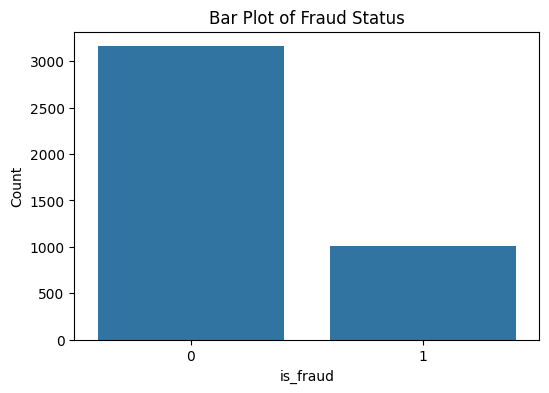

In [67]:
plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud', data=Fraud_clean)
plt.title('Bar Plot of Fraud Status')
plt.xlabel('is_fraud')
plt.ylabel('Count')
plt.show()

## Boxplot of Numerical Variables

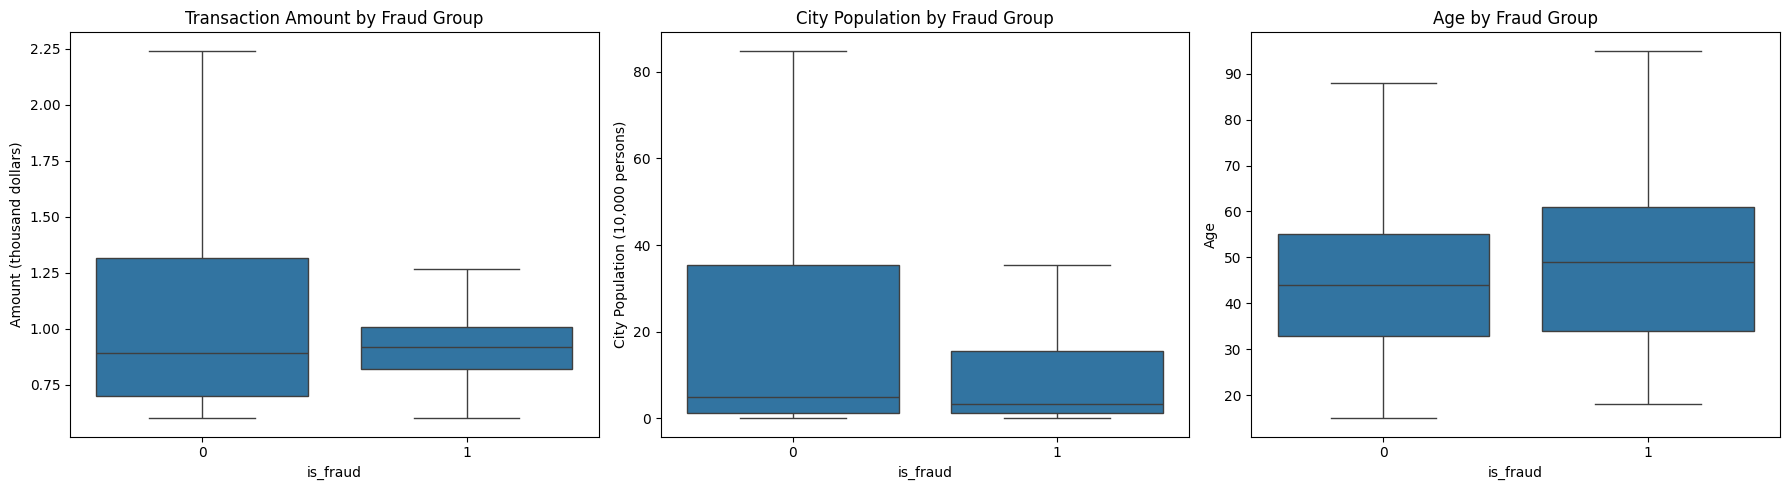

In [68]:
Fraud_clean["is_fraud"] = Fraud_clean["is_fraud"].astype(int)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=Fraud_clean, x="is_fraud", y="amt_thousand", ax=axes[0], showfliers=False)
axes[0].set_title("Transaction Amount by Fraud Group")
axes[0].set_xlabel("is_fraud")
axes[0].set_ylabel("Amount (thousand dollars)")

sns.boxplot(data=Fraud_clean, x="is_fraud", y="city_pop_thousand", ax=axes[1], showfliers=False)
axes[1].set_title("City Population by Fraud Group")
axes[1].set_xlabel("is_fraud")
axes[1].set_ylabel("City Population (10,000 persons)")

sns.boxplot(data=Fraud_clean, x="is_fraud", y="age", ax=axes[2], showfliers=False)
axes[2].set_title("Age by Fraud Group")
axes[2].set_xlabel("is_fraud")
axes[2].set_ylabel("Age")

plt.tight_layout()
plt.show()

## Contigency Table

In [69]:
cat_vars = ["category", "gender", "region", "late_night"]

for var in cat_vars:
    print(f"\nContingency Table: {var} vs is_fraud")
    print(pd.crosstab(Fraud_clean[var], Fraud_clean["is_fraud"]))


Contingency Table: category vs is_fraud
is_fraud          0    1
category                
entertainment    10    6
misc_net        405  264
misc_pos        405   17
shopping_net    896  506
shopping_pos   1118  212
travel          327    0

Contingency Table: gender vs is_fraud
is_fraud     0    1
gender             
F         1975  474
M         1186  531

Contingency Table: region vs is_fraud
is_fraud      0    1
region              
Midwest     836  308
Northeast   560  213
South      1255  341
West        510  143

Contingency Table: late_night vs is_fraud
is_fraud       0    1
late_night           
0           2425  149
1            736  856


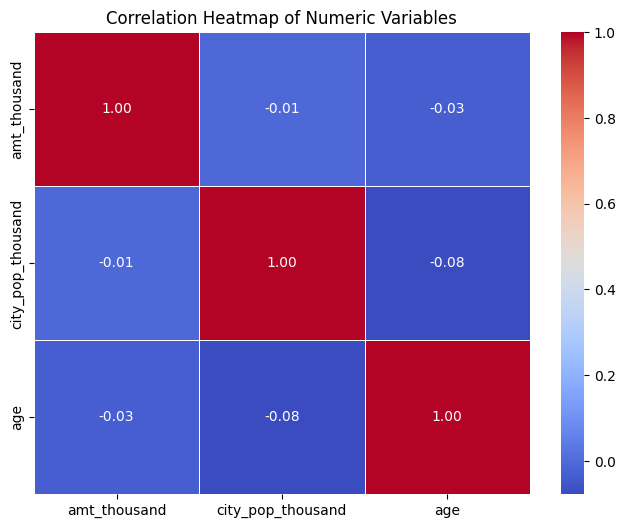

In [70]:
num_vars = ["amt_thousand", "city_pop_thousand", "age"]
corr_matrix = Fraud_clean[num_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

## Feature Engineering: One-Hot Encoding

In [71]:
Fraud_onehot = pd.get_dummies(
    Fraud_clean,
    columns=["category", "gender", "region"],
    drop_first=False,
    dtype=int
)

print(Fraud_onehot.head())
print(Fraud_onehot.columns)

     is_fraud  age  late_night  amt_thousand  city_pop_thousand  \
167         0   37           0       1.19945            186.140   
428         0   31           0       1.88153              0.530   
600         0   36           0       0.61678              0.467   
720         0   48           0       0.70559              1.368   
728         0   49           0       0.72414             46.563   

     category_entertainment  category_misc_net  category_misc_pos  \
167                       0                  0                  0   
428                       0                  0                  0   
600                       0                  0                  0   
720                       0                  0                  0   
728                       0                  0                  0   

     category_shopping_net  category_shopping_pos  category_travel  gender_F  \
167                      1                      0                0         1   
428                   

## Feature Engineering: Adding Interaction Term (city_pop_thousand * region)

In [72]:
region_dummies = pd.get_dummies(Fraud_clean["region"], prefix="region", drop_first=True, dtype=int)

Fraud_reg = pd.concat([Fraud_clean, region_dummies], axis=1)

for col in region_dummies.columns:
    Fraud_reg[f"citypop_x_{col}"] = Fraud_reg["city_pop_thousand"] * Fraud_reg[col]

print(Fraud_reg.head())

         category gender  is_fraud     region  age  late_night  amt_thousand  \
167  shopping_net      F         0      South   37           0       1.19945   
428  shopping_pos      F         0      South   31           0       1.88153   
600        travel      M         0      South   36           0       0.61678   
720  shopping_net      F         0  Northeast   48           0       0.70559   
728  shopping_net      F         0      South   49           0       0.72414   

     city_pop_thousand  region_Northeast  region_South  region_West  \
167            186.140                 0             1            0   
428              0.530                 0             1            0   
600              0.467                 0             1            0   
720              1.368                 1             0            0   
728             46.563                 0             1            0   

     citypop_x_region_Northeast  citypop_x_region_South  citypop_x_region_West  
167        

In [73]:
print(Fraud_clean.columns.tolist())

['category', 'gender', 'is_fraud', 'region', 'age', 'late_night', 'amt_thousand', 'city_pop_thousand']


## Logistic Regression Model

In [74]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt

# --------------------------------
# Step 1: One-hot encoding
# --------------------------------
Fraud_onehot = pd.get_dummies(
    Fraud_clean,
    columns=["category", "gender", "region"],
    drop_first=True,   # regression里更推荐True
    dtype=int
)

# 确保因变量是整数型0/1
Fraud_onehot["is_fraud"] = Fraud_onehot["is_fraud"].astype(int)

# --------------------------------
# Step 2: Define X and y
# --------------------------------
X = Fraud_onehot.drop(columns=["is_fraud"])
y = Fraud_onehot["is_fraud"]

# 加常数项
X = sm.add_constant(X)

# --------------------------------
# Step 3: Train-test split
# --------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# --------------------------------
# Step 4: Fit logistic regression
# --------------------------------
logit_model = sm.Logit(y_train, X_train).fit()
print(logit_model.summary())

# --------------------------------
# Step 5: Predict on test set
# --------------------------------
y_prob = logit_model.predict(X_test)
y_pred = (y_prob >= 0.5).astype(int)

# --------------------------------
# Step 6: Confusion matrix
# --------------------------------
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

# --------------------------------
# Step 7: Evaluation metrics
# --------------------------------
logit_accuracy = accuracy_score(y_test, y_pred)
logit_sensitivity = tp / (tp + fn)   # recall, true positive rate
logit_specificity = tn / (tn + fp)   # true negative rate
logit_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {logit_accuracy:.4f}")
print(f"Sensitivity: {logit_sensitivity:.4f}")
print(f"Specificity: {logit_specificity:.4f}")
print(f"AUC: {logit_auc:.4f}")

         Current function value: 0.339916
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:               is_fraud   No. Observations:                 3332
Model:                          Logit   Df Residuals:                     3318
Method:                           MLE   Df Model:                           13
Date:                Fri, 24 Apr 2026   Pseudo R-squ.:                  0.3848
Time:                        10:19:35   Log-Likelihood:                -1132.6
converged:                      False   LL-Null:                       -1841.2
Covariance Type:            nonrobust   LLR p-value:                3.140e-295
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -1.5315      0.715     -2.141      0.032      -2.934      -0.129
age                    8.822e-05

c:\Users\eyuey\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Machine Learning: Decision Trees

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, roc_curve

# --------------------------------
# Step 1: One-hot encoding
# --------------------------------
Fraud_onehot = pd.get_dummies(
    Fraud_clean,
    columns=["category", "gender", "region"],
    drop_first=True,
    dtype=int
)

Fraud_onehot["is_fraud"] = Fraud_onehot["is_fraud"].astype(int)

# --------------------------------
# Step 2: Define X and y
# --------------------------------
selected_cols = [
    "age",
    "late_night",
    "amt_thousand",
    "city_pop_thousand"
] + [col for col in Fraud_onehot.columns if col.startswith("gender_")
] + [col for col in Fraud_onehot.columns if col.startswith("region_")
] + [col for col in Fraud_onehot.columns if col.startswith("category_")]

X = Fraud_onehot[selected_cols]
y = Fraud_onehot["is_fraud"]

# --------------------------------
# Step 3: Train-test split
# --------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# --------------------------------
# Step 4: Fit decision tree
# --------------------------------
tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10
)

tree_model.fit(X_train, y_train)

# --------------------------------
# Step 5: Predict on test set
# --------------------------------
y_pred = tree_model.predict(X_test)
y_prob = tree_model.predict_proba(X_test)[:, 1]

# --------------------------------
# Step 6: Confusion matrix
# --------------------------------
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

# --------------------------------
# Step 7: Evaluation metrics
# --------------------------------
tree_accuracy = accuracy_score(y_test, y_pred)
tree_sensitivity = tp / (tp + fn)
tree_specificity = tn / (tn + fp)
tree_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {tree_accuracy:.4f}")
print(f"Sensitivity: {tree_sensitivity:.4f}")
print(f"Specificity: {tree_specificity:.4f}")
print(f"AUC: {tree_auc:.4f}")

Confusion Matrix:
[[563  70]
 [ 49 152]]
Accuracy: 0.8573
Sensitivity: 0.7562
Specificity: 0.8894
AUC: 0.9114


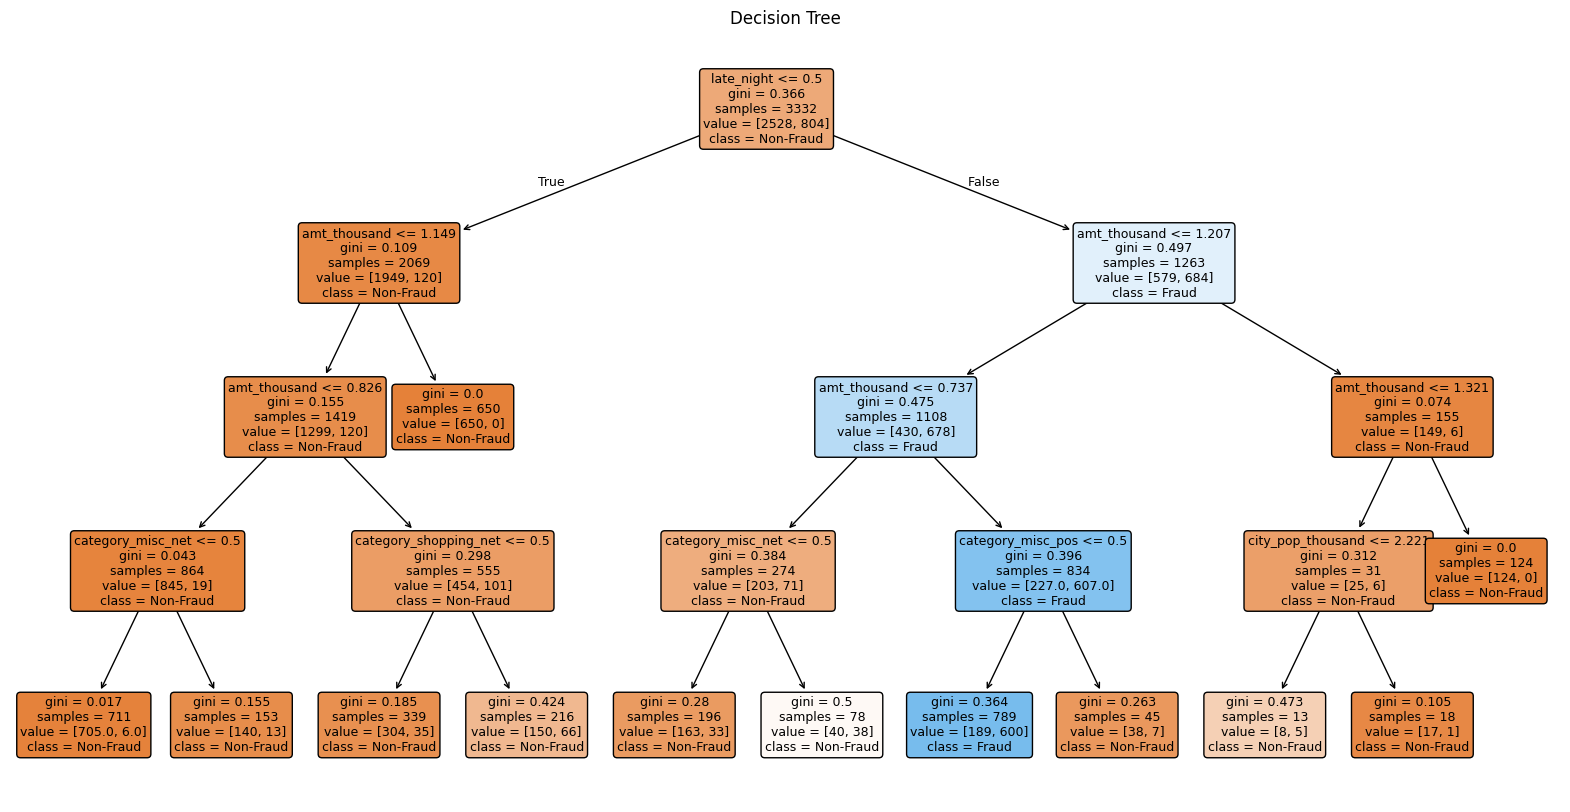

In [76]:
plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Non-Fraud", "Fraud"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree")
plt.show()

In [77]:
import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree_model.feature_importances_
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

print(importance_df)

                  Feature  Importance
1              late_night    0.583406
2            amt_thousand    0.326873
9       category_misc_pos    0.049555
8       category_misc_net    0.020387
10  category_shopping_net    0.017179
3       city_pop_thousand    0.002600
0                     age    0.000000
4                gender_M    0.000000
5        region_Northeast    0.000000
7             region_West    0.000000
6            region_South    0.000000
11  category_shopping_pos    0.000000
12        category_travel    0.000000


In [78]:
importance_df["Variable_Group"] = importance_df["Feature"].replace({
    "gender_M": "gender",
    "region_Northeast": "region",
    "region_South": "region",
    "region_West": "region",
    "category_misc_pos": "category",
    "category_misc_net": "category",
    "category_shopping_net": "category",
    "category_shopping_pos": "category",
    "category_travel": "category"
})

group_importance = (
    importance_df
    .groupby("Variable_Group", as_index=False)["Importance"]
    .sum()
    .sort_values(by="Importance", ascending=False)
)

print(group_importance)

      Variable_Group  Importance
5         late_night    0.583406
1       amt_thousand    0.326873
2           category    0.087121
3  city_pop_thousand    0.002600
0                age    0.000000
4             gender    0.000000
6             region    0.000000


## Machine Learning: XGBoost

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, roc_curve

# --------------------------------
# Step 1: One-hot encoding
# --------------------------------
Fraud_onehot = pd.get_dummies(
    Fraud_clean,
    columns=["category", "gender", "region"],
    drop_first=True,
    dtype=int
)

Fraud_onehot["is_fraud"] = Fraud_onehot["is_fraud"].astype(int)

# --------------------------------
# Step 2: Define X and y
# --------------------------------
selected_cols = [
    "age",
    "late_night",
    "amt_thousand",
    "city_pop_thousand"
] + [col for col in Fraud_onehot.columns if col.startswith("gender_")
] + [col for col in Fraud_onehot.columns if col.startswith("region_")
] + [col for col in Fraud_onehot.columns if col.startswith("category_")]

X = Fraud_onehot[selected_cols]
y = Fraud_onehot["is_fraud"]

# --------------------------------
# Step 3: Train-test split
# --------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# --------------------------------
# Step 4: Fit XGBoost
# --------------------------------
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

# --------------------------------
# Step 5: Predict on test set
# --------------------------------
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# --------------------------------
# Step 6: Confusion matrix
# --------------------------------
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

# --------------------------------
# Step 7: Metrics
# --------------------------------
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_sensitivity = tp / (tp + fn)
xgb_specificity = tn / (tn + fp)
xgb_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {xgb_accuracy:.4f}")
print(f"Sensitivity: {xgb_sensitivity:.4f}")
print(f"Specificity: {xgb_specificity:.4f}")
print(f"AUC: {xgb_auc:.4f}")

Confusion Matrix:
[[583  50]
 [ 33 168]]
Accuracy: 0.9005
Sensitivity: 0.8358
Specificity: 0.9210
AUC: 0.9650


In [80]:
importance_df_xgb = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance_df_xgb)

                  Feature  Importance
1              late_night    0.586693
2            amt_thousand    0.069008
9       category_misc_pos    0.062026
10  category_shopping_net    0.048301
12        category_travel    0.041039
8       category_misc_net    0.037763
11  category_shopping_pos    0.035454
4                gender_M    0.026291
0                     age    0.023543
3       city_pop_thousand    0.023433
7             region_West    0.016659
5        region_Northeast    0.015489
6            region_South    0.014300


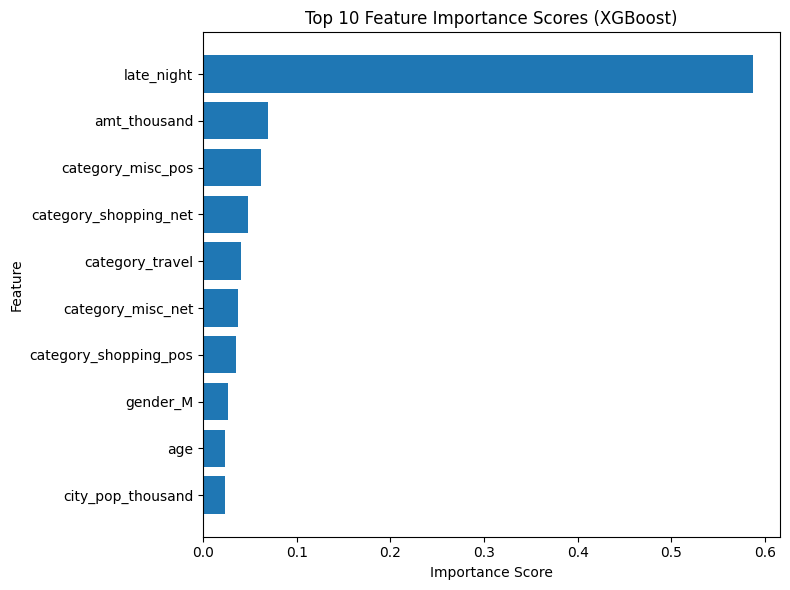

In [81]:
top10_xgb = importance_df_xgb.head(10).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(top10_xgb["Feature"], top10_xgb["Importance"])
plt.title("Top 10 Feature Importance Scores (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Overview of Validations

In [82]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "XGBoost"],
    "Accuracy": [logit_accuracy, tree_accuracy, accuracy],
    "Sensitivity": [logit_sensitivity, tree_sensitivity, sensitivity],
    "Specificity": [logit_specificity, tree_specificity, specificity],
    "AUC": [logit_auc, tree_auc, auc]
})

print(results)

                 Model  Accuracy  Sensitivity  Specificity       AUC
0  Logistic Regression  0.852518     0.736318     0.889415  0.894414
1        Decision Tree  0.857314     0.756219     0.889415  0.911383
2              XGBoost  0.900480     0.835821     0.921011  0.964954
